In [1]:
# Importar librerías necesarias

# Crear y entrenar los modelos
import tensorflow as tf
# Trabajar con arreglos numéricos fácilmente
import numpy as np
# Graficar resultados
import matplotlib.pyplot as plt

In [23]:
# Datos de entrada y salida, son los datos con los que el modelo será entrenado
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

In [24]:
# Crear un modelo de tipo secuencial
# Se usa Input(shape) como primera capa para definir la forma de entrada, es la forma recomendada
# de especificar la entrada en modelos Sequential
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=[1]),
    # Capa densa (fully connected): cada neurona se conecta con todas las de la siguiente capa
    tf.keras.layers.Dense(units=1)
])

In [25]:
# Compilar el modelo, esto prepara al modelo para el entrenamiento
modelo.compile(
    # Adam, es un algoritmo que le permite a la red saber como ajustar los pesos y sesgos de manera eficiente
    # Le pasamos la tasa de aprendizaje, le dice que tanto ajustar los pesos y sesgos
    optimizer=tf.keras.optimizers.Adam(0.1),
    # Error cuadrático medio: considera que una poca cantidad de errores grandes es peor que una gran cantidad de errores pequeños
    loss='mean_squared_error'
)

In [26]:
print('=> Comenzar entrenamiento...')
historial = modelo.fit(celsius, fahrenheit, epochs=1000, verbose=False)
print('=> Modelo entrenado!')

=> Comenzar entrenamiento...
=> Modelo entrenado!


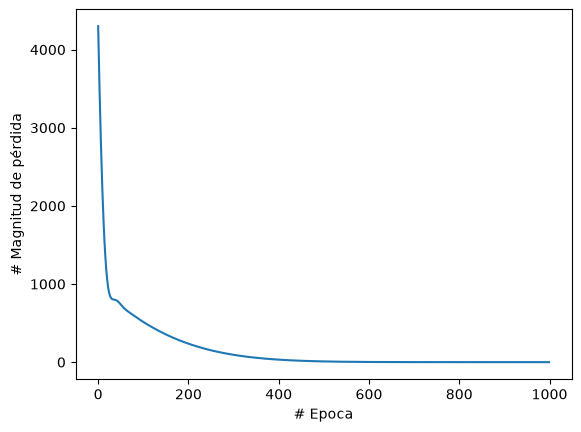

In [39]:
# Graficar los resultados de la función de pérdida (loss) durante el entrenamiento,
# esto nos dice que tan mal están los resultados de la red en cada vuelta que dio
plt.xlabel("# Epoca")
plt.ylabel("# Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.show()

In [40]:
# Hacer predicciones con el modelo entrenado
result = modelo.predict(np.array([[100.0]], dtype=float))
print(f'El resultado es: {str(result[0][0])} Fahrenheit')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
El resultado es: 211.74246 Fahrenheit


In [48]:
# Ver los valores de pesos y sesgos del modelo entrenado
print(modelo.layers[0].get_weights())

[array([[1.7982492]], dtype=float32), array([31.917547], dtype=float32)]
